In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# Load the MNIST dataset
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train_full.shape)
print(y_train_full.shape)


(60000, 28, 28)
(60000,)


In [4]:
print(x_train_full)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


In [5]:
print(x_train_full[2])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0
    0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0   0   0   

In [6]:
print(y_train_full)

[5 0 4 ... 5 6 8]


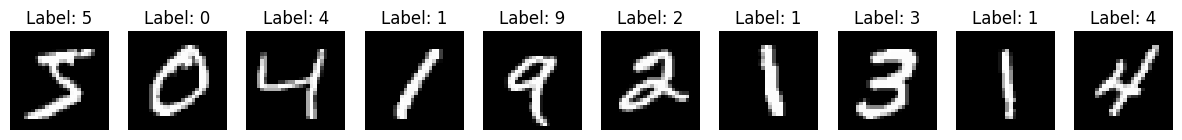

In [7]:
#visualize some of the images
import matplotlib.pyplot as plt
import numpy as np

# Number of digits to display
num_images = 10

plt.figure(figsize=(15, 4))
for i in range(num_images):
    # pick the image
    img = x_train_full[i]

    # decode one-hot label
    label = y_train_full[i]

    # plot
    plt.subplot(1, num_images, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

In [8]:
# Normalize the pixel values (0-255) to range [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
# Reshape the input data to have a single channel (for CNN compatibility)
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [10]:
print(x_train_full.shape)

(60000, 28, 28, 1)


In [11]:
# Split training data into 50% train, 25% validation, 25% test
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.5, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, test_size=0.5, random_state=42)

In [12]:
print(y_train[0])
# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)
print(y_train_cat[0])
print(y_train_cat[1].shape)

8
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
(10,)


In [13]:
# Build a simple CNN model
model = tf.keras.Sequential([
    #####
    tf.keras.layers.Conv2D(4, (7, 7), input_shape=(28, 28, 1)),
    #tf.keras.layers.Conv2D(4, (7, 7)),
    tf.keras.layers.Activation('sigmoid'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((3, 3)),
    #####
    tf.keras.layers.Conv2D(2, (3, 3), activation='sigmoid'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    #####
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 4)      │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 22, 22, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 22, 22, 4)      │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 2)        │            74 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 604 (2.36 KB)

 Trainable params: 596 (2.33 KB)

 Non-trainable params: 8 (32.00 B)

None


In [16]:
# Train the model and store the history
history = model.fit(x_train, y_train_cat, epochs=10, validation_data=(x_val, y_val_cat))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3069 - loss: 2.0697 - val_accuracy: 0.4181 - val_loss: 1.7692
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 961us/step - accuracy: 0.5683 - loss: 1.4644 - val_accuracy: 0.6009 - val_loss: 1.2807
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - accuracy: 0.6565 - loss: 1.1043 - val_accuracy: 0.6704 - val_loss: 1.0112
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - accuracy: 0.6883 - loss: 0.9332 - val_accuracy: 0.6992 - val_loss: 0.9084
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.7137 - loss: 0.8434 - val_accuracy: 0.7145 - val_loss: 0.8295
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 995us/step - accuracy: 0.7316 - loss: 0.7840 - val_accuracy: 0.7383 - val_loss: 0.7714
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 894us/step - accuracy: 0.7480 - loss: 0.7388 - val_accuracy: 0.7391 - val_loss: 0.7397
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - accuracy: 0.7635 - loss: 0.7006 - va

In [17]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f'\nTest accuracy: {test_acc}')

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - accuracy: 0.7882 - loss: 0.6321

Test accuracy: 0.7882000207901001


In [18]:
# Plot training & validation accuracy and loss
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

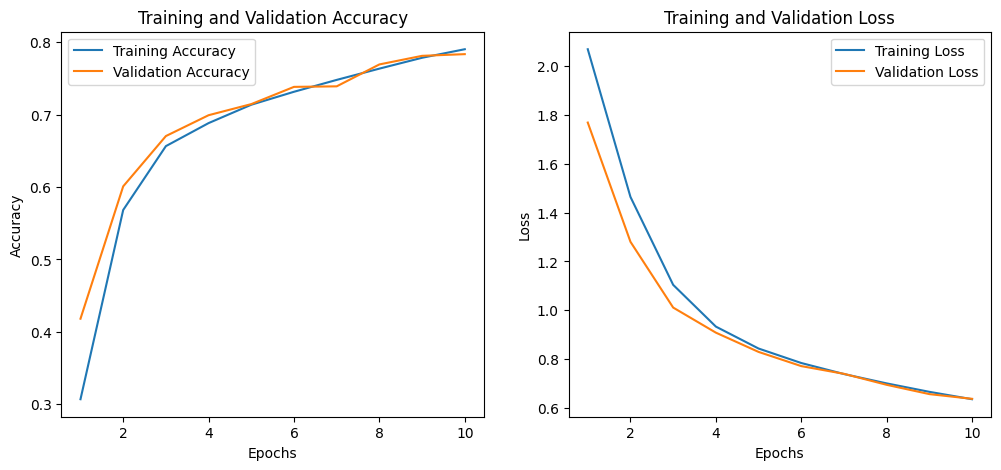

In [19]:

# Call the function to plot the training history
plot_training_history(history)

In [20]:
# Generate ROC curves for each digit (one-vs-rest)
def plot_roc_curves(y_true, y_pred):
    y_true_bin = label_binarize(y_true, classes=np.arange(10))

    plt.figure(figsize=(12, 8))
    colors = plt.get_cmap('tab10')

    for i in range(10):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])

        # Compute the standard ROC AUC before any transformation
        roc_auc = auc(fpr, tpr)

        # Exclude zero FPR values to avoid division by zero
        mask = fpr > 0

        plt.plot(
            tpr[mask],
            1.0 / fpr[mask],
            color=colors(i),
            lw=2,
            label=f'Digit {i} (AUC = {roc_auc:.5f})'
        )

    plt.yscale("log")
    plt.xlim([0.7, 1.0])
    plt.ylabel('1 / False Positive Rate')
    plt.xlabel('True Positive Rate')
    plt.title('ROC Curves for Each Digit')
    plt.legend(loc='lower left')
    plt.show()

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step


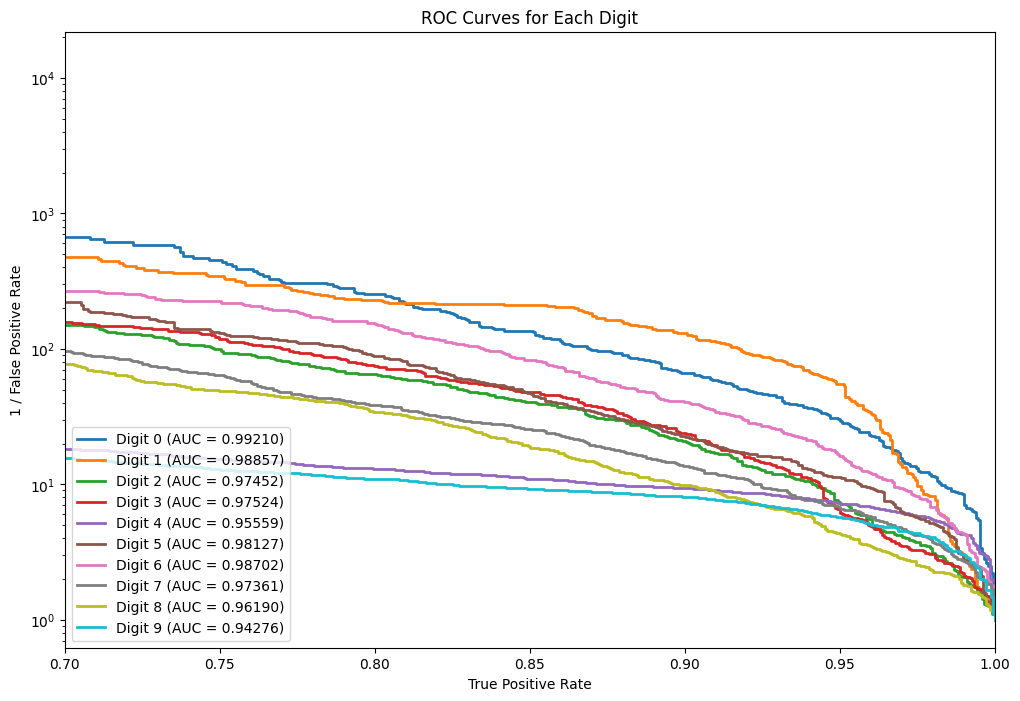

In [21]:
# Get model predictions
y_pred_prob = model.predict(x_test)
# Plot ROC curves
plot_roc_curves(y_test, y_pred_prob)

In [22]:
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred):
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

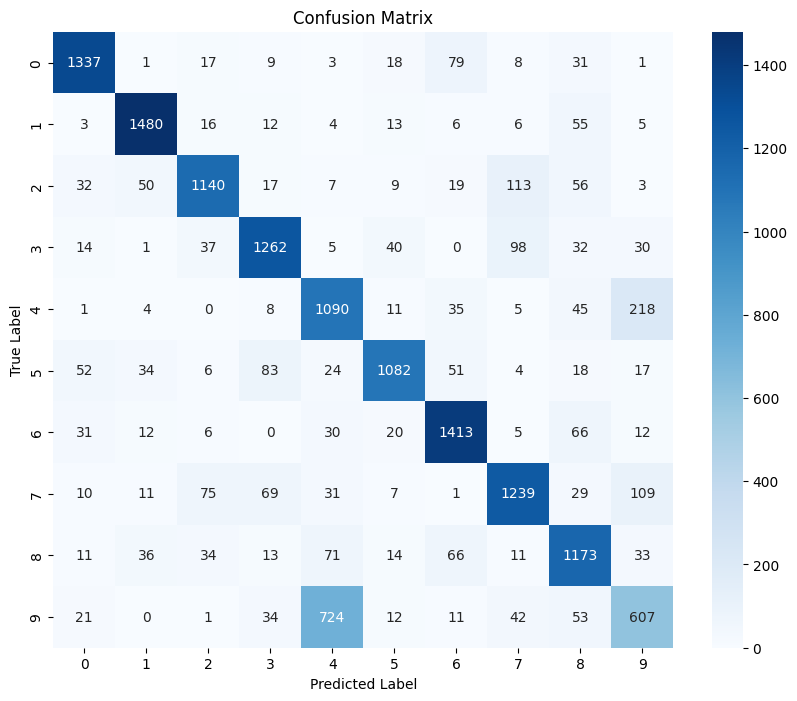

In [23]:
# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred_prob)